In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA

In [ ]:
# Load temporal dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)

# Convert to datetime
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

print(df.head())


            Passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121


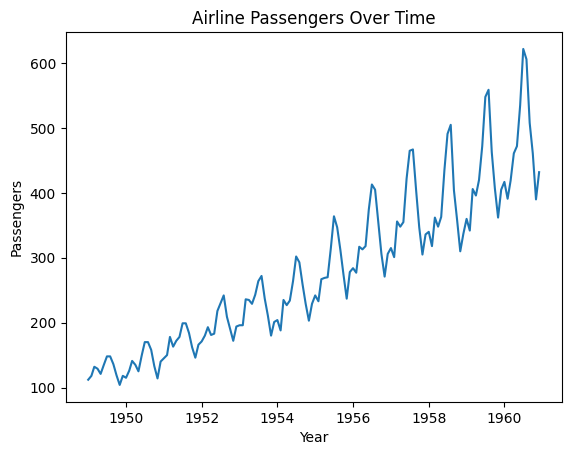

In [ ]:
plt.figure()
plt.plot(df)
plt.title("Airline Passengers Over Time")
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.show()

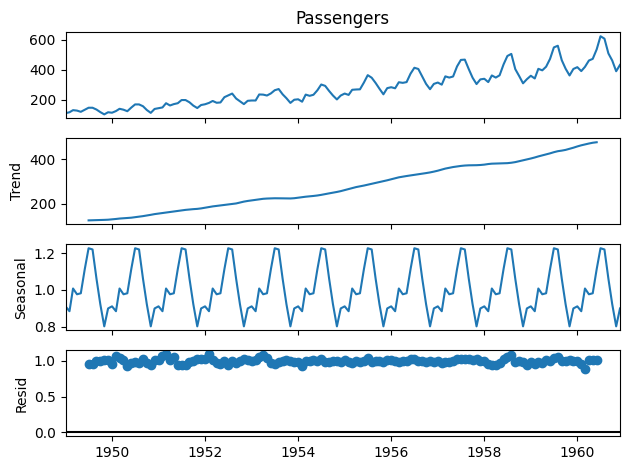

In [ ]:
decomposition = seasonal_decompose(df['Passengers'], model='multiplicative')

decomposition.plot()
plt.show()

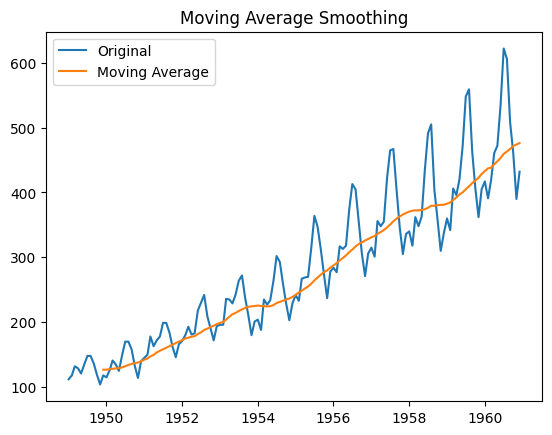

In [ ]:
df['Moving_Avg'] = df['Passengers'].rolling(window=12).mean()

plt.figure()
plt.plot(df['Passengers'], label='Original')
plt.plot(df['Moving_Avg'], label='Moving Average')
plt.legend()
plt.title("Moving Average Smoothing")
plt.show()

In [ ]:
model = ARIMA(df['Passengers'], order=(5,1,0))
model_fit = model.fit()

print(model_fit.summary())


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  144
Model:                 ARIMA(5, 1, 0)   Log Likelihood                -689.067
Date:                Sat, 18 Apr 2026   AIC                           1390.135
Time:                        04:59:53   BIC                           1407.912
Sample:                    01-01-1949   HQIC                          1397.358
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3223      0.097      3.334      0.001       0.133       0.512
ar.L2         -0.2170      0.078     -2.776      0.006      -0.370      -0.064
ar.L3         -0.0646      0.071     -0.915      0.3

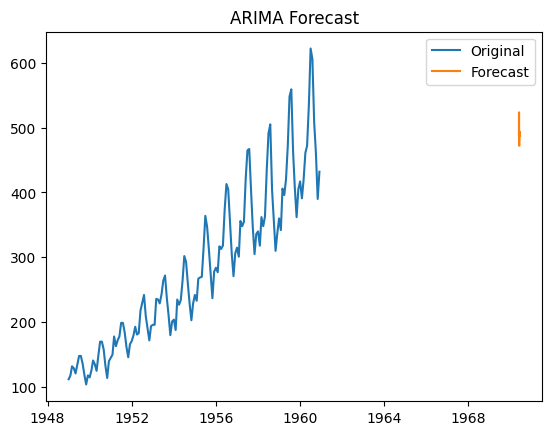

In [ ]:
forecast = model_fit.forecast(steps=12)

# Plot forecast
plt.figure()
plt.plot(df['Passengers'], label='Original')
plt.plot(range(len(df), len(df)+12), forecast, label='Forecast')
plt.legend()
plt.title("ARIMA Forecast")
plt.show()